# Stack Overflow Developer Survey Analysis (2020–2024)

## 1. Introduction

### Research Objectives:
1. Analyze language usage trends over 5 years
2. Examine relationships between sentiment metrics (Loved, Desired, Admired) and Usage
3. Identify growth patterns and developer preference shifts
4. Provide data-driven insights for technology adoption strategies

### Metrics Used in This Study
- Usage: Percentage of respondents who reported using a language
- Loved: Percentage of developers who want to continue using a language
- Desired: Percentage of developers who want to learn or adopt a language
- Admired: Combined indicator of satisfaction and future interest

## 2. Data Sources

### Libraries

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

### Loading Data Frames

In [4]:
YEARS = range(2020, 2025)

data_frames: dict = {}

for year in YEARS:
    path = f"../data/survey_{year}.csv"
    data_frames[year] = pd.read_csv(path)

In [5]:
# Testing purposes only

for year, df in data_frames.items():
    print(year, df.shape)

2020 (64461, 61)
2021 (83439, 48)
2022 (73268, 79)
2023 (89184, 84)
2024 (65437, 114)


## 3. Analysis of Usage Trends

In [66]:
def calculate_usage(df, column: str="LanguageHaveWorkedWith"):
    """
    Calculate usage percentage for a multi-select language column.
    Matches Stack Overflow Developer Survey methodology.
    """
    # Removes missing responses
    responses = df[column].dropna()

    # Total number of respondents who answered the question
    total_respondents = responses.shape[0]

    # Count how many times each language appears
    language_counts = responses.str.split(";").explode().value_counts()

    # Convert to percentage
    usage_percentage = ((language_counts / total_respondents) * 100)

    return usage_percentage.sort_values(ascending=False)

In [67]:
usage_by_year: dict = {}

for year, data_frame in data_frames.items():
    usage_by_year[year] = calculate_usage(
        data_frame,
        "LanguageHaveWorkedWith"
    )

print(round(usage_by_year[2024], 2).head(20))

LanguageHaveWorkedWith
JavaScript                 62.75
HTML/CSS                   53.25
Python                     51.42
SQL                        51.35
TypeScript                 38.75
Bash/Shell (all shells)    34.17
Java                       30.53
C#                         27.31
C++                        23.14
C                          20.39
PHP                        18.33
PowerShell                 13.94
Go                         13.56
Rust                       12.65
Kotlin                      9.48
Lua                         6.24
Dart                        6.02
Assembly                    5.41
Ruby                        5.27
Swift                       4.74
Name: count, dtype: float64


In [146]:
usage_trends = pd.DataFrame(usage_by_year)

# List of excluded non-programming language options
exclude = ["Node.js"]

# Drops rows of excluded non-programming language options
usage_trends = usage_trends.drop(index=exclude, errors="ignore")

print(round(usage_trends, 2).sort_values(by=YEARS[-1], ascending=False))

                          2020   2021   2022   2023   2024
LanguageHaveWorkedWith                                    
JavaScript               67.66  65.07  65.44  63.93  62.75
HTML/CSS                 63.06  56.17  55.15  53.24  53.25
Python                   44.07  48.32  48.12  49.53  51.42
SQL                      54.75  47.15  49.49  48.91  51.35
TypeScript               25.41  30.25  34.87  39.06  38.75
Bash/Shell (all shells)  33.08  27.18  29.10  32.54  34.17
Java                     40.21  35.41  33.31  30.71  30.53
C#                       31.44  27.91  28.01  27.76  27.31
C++                      23.89  24.35  22.58  22.53  23.14
C                        21.76  21.04  19.29  19.44  20.39
PHP                      26.15  22.01  20.89  18.68  18.33
PowerShell                 NaN  10.77  12.08  13.66  13.94
Go                        8.78   9.57  11.16  13.30  13.56
Rust                      5.10   7.04   9.33  13.11  12.65
Kotlin                    7.79   8.34   9.17   9.11   9.

In [93]:
usage_metrics = pd.DataFrame(index=usage_trends.index)

usage_metrics["Mean Usage"] = usage_trends.mean(axis="columns")
usage_metrics["5-Year Change"] = usage_trends[YEARS[-1]] - usage_trends[YEARS[0]]
usage_metrics["Yearly Change"] = usage_metrics["5-Year Change"] / 4
usage_metrics["Growth Rate"] = ((usage_trends[YEARS[-1]] - usage_trends[YEARS[0]]) / usage_trends[YEARS[0]]) * 100

print(round(usage_metrics, 2).sort_values(by="Mean Usage", ascending=False).head(25))

                         Mean Usage  5-Year Change  Yearly Change  Growth Rate
LanguageHaveWorkedWith                                                        
JavaScript                    64.97          -4.91          -1.23        -7.25
HTML/CSS                      56.17          -9.80          -2.45       -15.55
SQL                           50.33          -3.39          -0.85        -6.20
Python                        48.29           7.35           1.84        16.67
Java                          34.03          -9.69          -2.42       -24.09
TypeScript                    33.67          13.34           3.34        52.51
Bash/Shell (all shells)       31.21           1.09           0.27         3.28
C#                            28.49          -4.13          -1.03       -13.13
C++                           23.30          -0.75          -0.19        -3.12
PHP                           21.21          -7.83          -1.96       -29.92
C                             20.39          -1.37  

In [71]:
top_20_languages_by_usage = (
    usage_trends
    .sort_values(by=2024, ascending=False)
    .head(20)
)

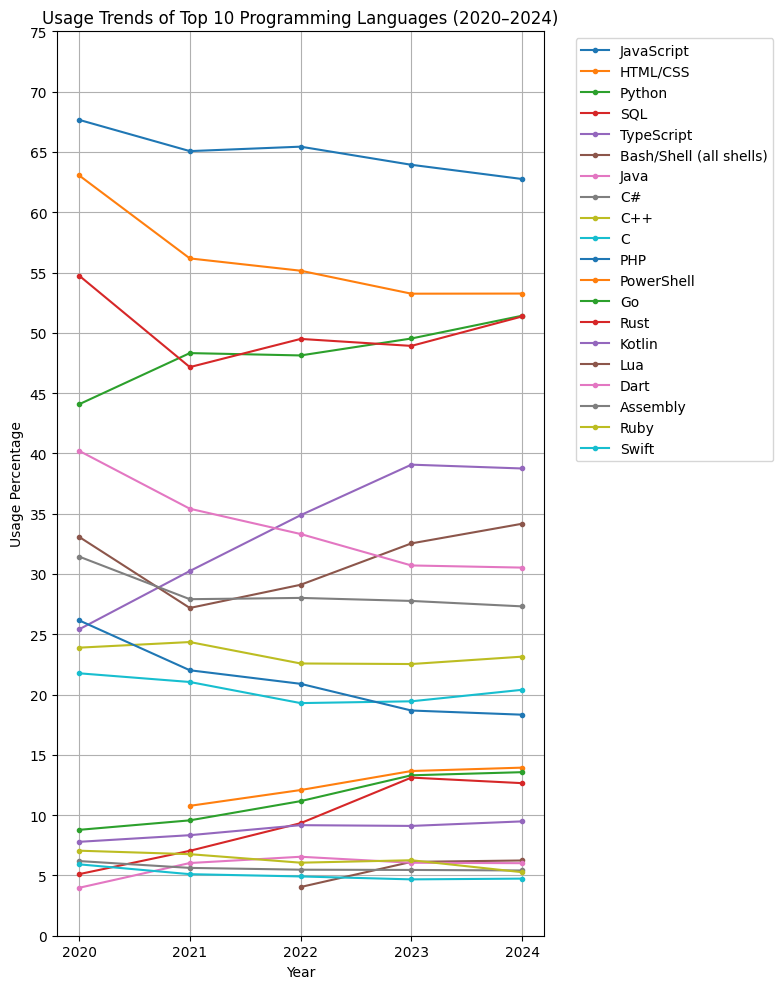

In [ ]:
plt.figure(figsize=(8, 10))

for language in top_20_languages_by_usage.index:
    plt.plot(
        top_20_languages_by_usage.columns,
        top_20_languages_by_usage.loc[language],
        marker=".",
        label=language
    )

plt.xlabel("Year")
plt.ylabel("Usage Percentage")

plt.xticks(YEARS)
plt.yticks(range(0, 80, 5))

plt.title("Usage Trends of Top 10 Programming Languages (2020–2024)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.grid(True)
plt.tight_layout()
plt.show()


In [134]:
top_5_languages_by_relative_growth = usage_metrics.sort_values(
    by="Growth Rate", ascending=False
).head(5)

top_5_languages_by_relative_decline = usage_metrics.sort_values(
    by="Growth Rate", ascending=True
).head(5)

In [135]:
def plot_language_trend(language):
    values = usage_trends.loc[language, YEARS]

    values.plot(
        marker="o",
        title=f"{language} Usage Trend (2020–2024)"
    )
    plt.xlabel("Year")
    plt.ylabel("Usage Percentage")

    plt.xticks(YEARS)

    y_max = int(max(10, min(100, round(values.max() * 1.25, -1))))
    plt.ylim(0, y_max)
    plt.yticks(range(0, y_max + 1, 5))

    plt.grid(True)
    plt.show()

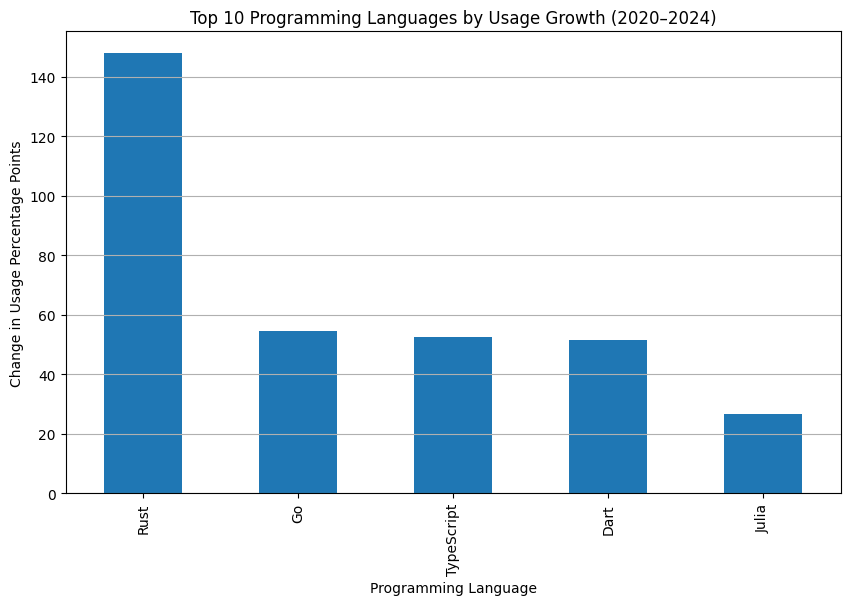

In [ ]:
plt.figure(figsize=(10, 6))
top_5_languages_by_relative_growth["Growth Rate"].plot(kind="bar")
plt.title("Top 10 Programming Languages by Usage Growth Rate (2020–2024)")
plt.ylabel("Change in Usage Percentage Points")
plt.xlabel("Programming Language")
plt.grid(axis="y")
plt.show()

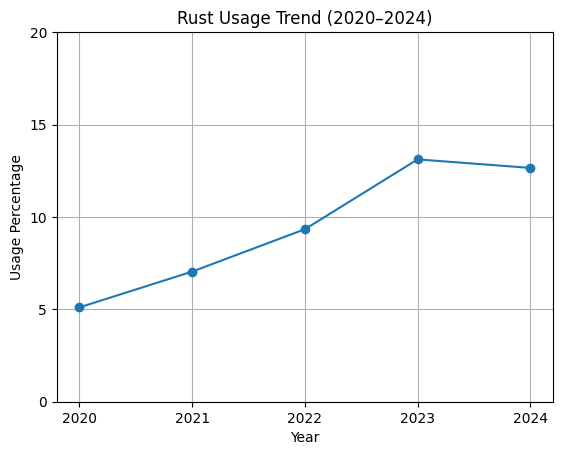

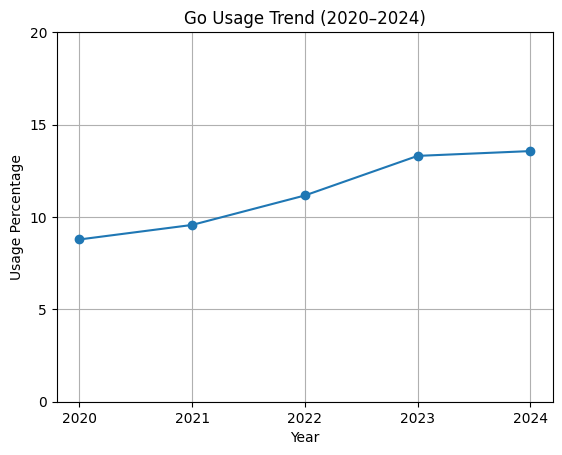

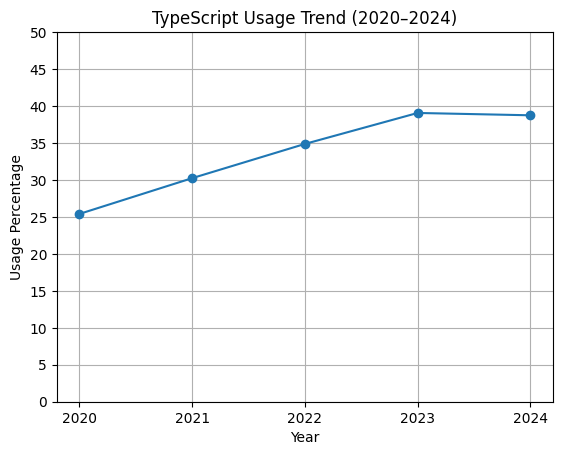

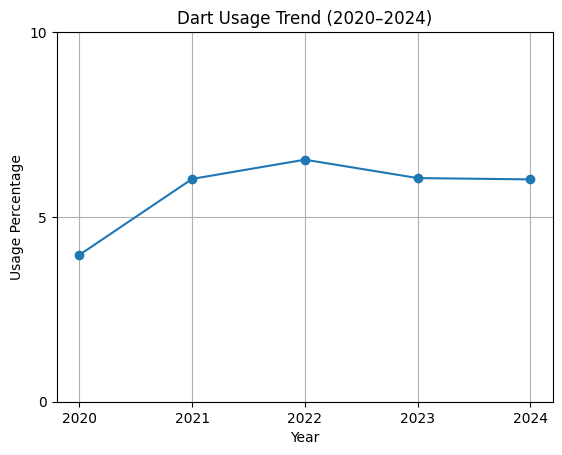

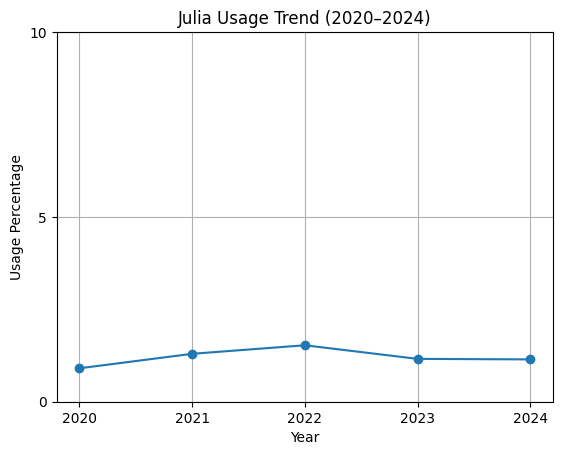

In [136]:
for language in top_5_languages_by_relative_growth.index:
    plot_language_trend(language)

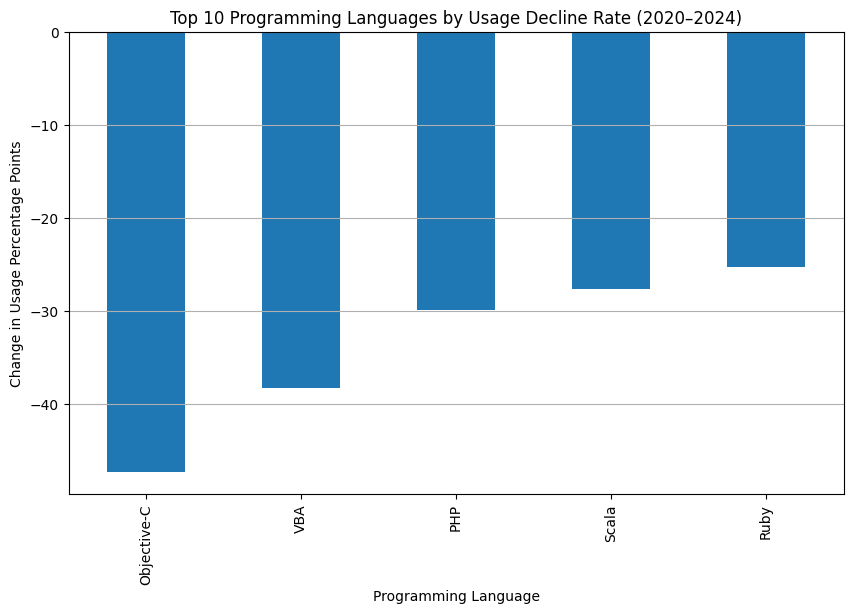

In [149]:
plt.figure(figsize=(10, 6))
top_5_languages_by_relative_decline["Growth Rate"].plot(kind="bar")
plt.title("Top 10 Programming Languages by Usage Decline Rate (2020–2024)")
plt.ylabel("Change in Usage Percentage Points")
plt.xlabel("Programming Language")
plt.grid(axis="y")
plt.show()

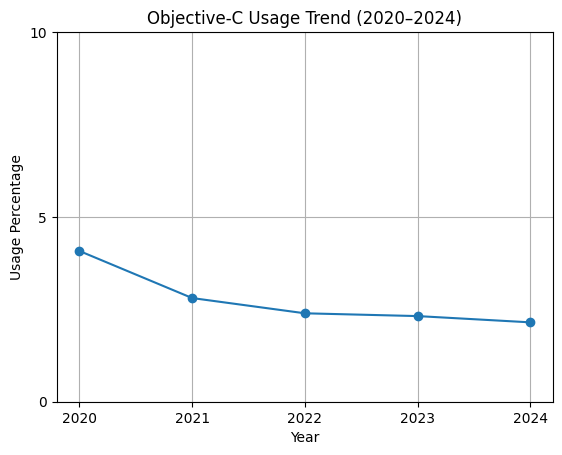

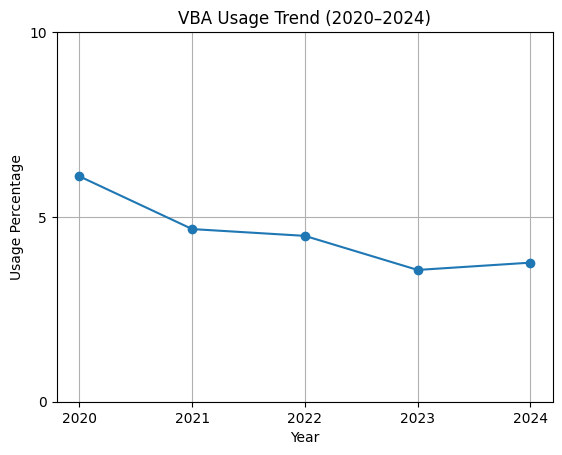

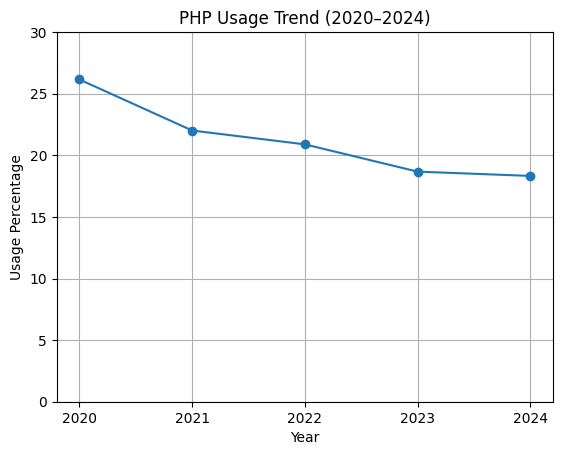

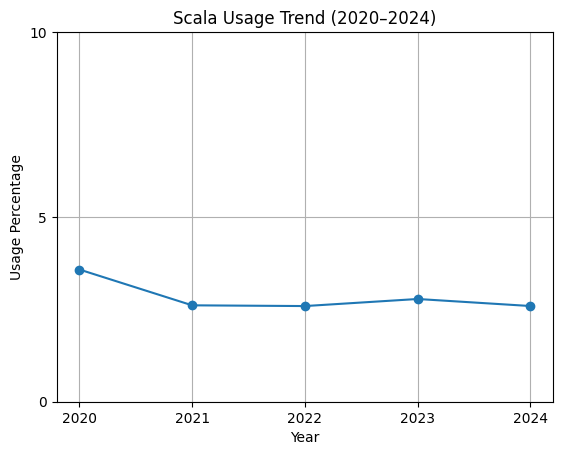

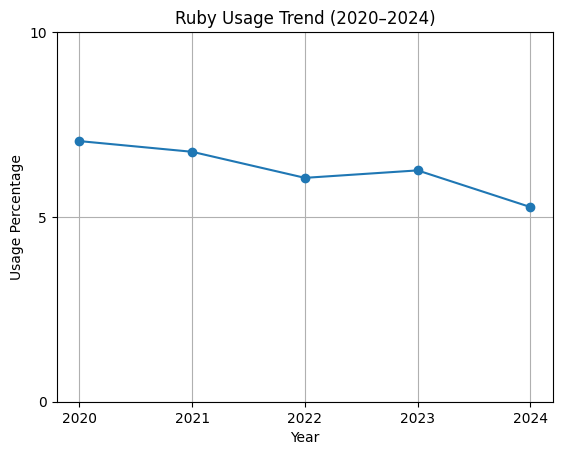

In [138]:
for language in top_5_languages_by_relative_decline.index:
    plot_language_trend(language)


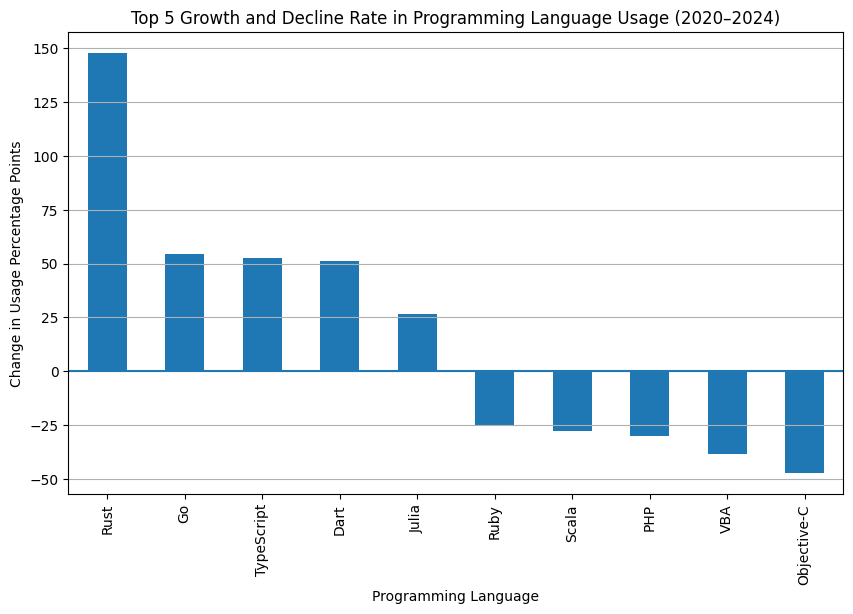

In [154]:
top_combined = pd.concat([
    top_5_languages_by_relative_growth["Growth Rate"],
    top_5_languages_by_relative_decline["Growth Rate"][::-1]
])

plt.figure(figsize=(10, 6))
top_combined.plot(kind="bar")
plt.title("Top 5 Growth and Decline Rate in Programming Language Usage (2020–2024)")
plt.ylabel("Change in Usage Percentage Points")
plt.xlabel("Programming Language")
plt.axhline(0)
plt.grid(axis="y")
plt.show()

## 4. Analysis of Loved and Desired Metrics

## 5. Comparative Trends Across Languages

## 6. Summary of Key Findings